# Actividad Evaluable: Limpieza de datos
El Arte de la Analítica  
Profesor: Aram Baruch González Pérez  

*   Michelle Rergis Novelo                 A01798576  
*   Min Che Kim                            A01750338  
*   Jennyfer Nahomi Jasso Hernández        A01749898  


## Inspección de datos
Revisar las anomalías en los datos y definir el camino a seguir.

In [1]:
import pandas as pd

# Cargar el archivo CSV
df = pd.read_csv('Actividad/bike_buyers.csv')

### 1. Mostrar las primeras filas para una inspección inicial


In [2]:
print("Primeras filas del DataFrame:")
df.head()

Primeras filas del DataFrame:


,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12591,Married,Female,"30,000",4.0,Graduate Degree,Clerical,Yes,0.0,0-1 Miles,Europe,45.0,No
1,14058,Single,Male,"70,000",0.0,Bachelors,Professional,No,1.0,5-10 Miles,Pacific,41.0,Yes
2,23962,Married,Female,"10,000",0.0,Partial High School,Manual,Yes,2.0,1-2 Miles,Europe,32.0,No
3,23419,Single,Female,"70,000",5.0,Bachelors,Professional,Yes,3.0,10+ Miles,Pacific,39.0,No
4,21940,Married,Male,"90,000",5.0,Graduate Degree,Professional,Yes,0.0,0-1 Miles,North America,47.0,Yes


### 2. Revisar los tipos de datos


In [3]:
print("\nInformación del DataFrame:\n")
df.info()


Información del DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1251 entries, 0 to 1250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1251 non-null   int64  
 1   Marital Status    1244 non-null   object 
 2   Gender            1238 non-null   object 
 3   Income            1243 non-null   object 
 4   Children          1238 non-null   float64
 5   Education         1251 non-null   object 
 6   Occupation        1251 non-null   object 
 7   Home Owner        1247 non-null   object 
 8   Cars              1242 non-null   float64
 9   Commute Distance  1251 non-null   object 
 10  Region            1251 non-null   object 
 11  Age               1238 non-null   float64
 12  Purchased Bike    1251 non-null   object 
dtypes: float64(3), int64(1), object(9)
memory usage: 127.2+ KB


### 3. Verificar datos faltantes

In [4]:
print("\nDatos faltantes por columna:\n")
print(df.isnull().sum())


Datos faltantes por columna:

ID                   0
Marital Status       7
Gender              13
Income               8
Children            13
Education            0
Occupation           0
Home Owner           4
Cars                 9
Commute Distance     0
Region               0
Age                 13
Purchased Bike       0
dtype: int64


Según lo obtenido podemos considerar que en su totalidadno muchos datos son nulos en cada columna, por lo que no es necesario eliminar alguna.

### 4. Revisamos estadísticas descriptivas para valores numéricos
* No existe algún dato que pueda tener una divergencia grande

In [5]:
print("\nEstadísticas descriptivas de las columnas numéricas:")
df.describe() 


Estadísticas descriptivas de las columnas numéricas:


,ID,Children,Cars,Age
count,1251.000000,1238.000000,1242.000000,1238.000000
mean,20030.208633,1.929725,1.479066,44.058966
std,5331.451777,1.638977,1.121885,11.271138
min,11000.000000,0.000000,0.000000,25.000000
25%,15465.000000,0.000000,1.000000,35.000000
50%,19731.000000,2.000000,1.000000,43.000000
75%,24549.000000,3.000000,2.000000,52.000000
max,29447.000000,5.000000,4.000000,89.000000


### 5. Revisar los datos atípicos
* Covertimos los datos de Income en número para poder graficarlo


In [6]:
df["Income"] = pd.to_numeric(df["Income"].str.replace(",",""))

Gráficas (cajas y bigotes, histograma, kernel)

* Income

<Axes: >

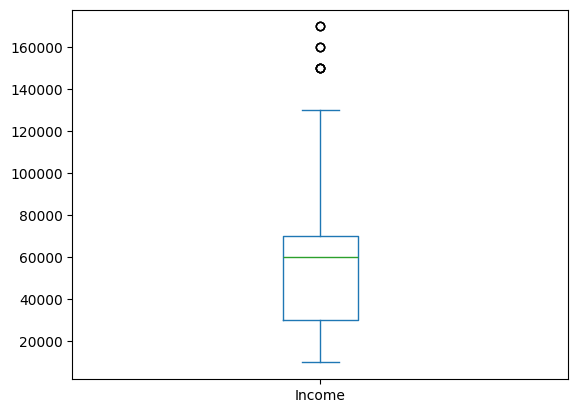

In [7]:
df["Income"].plot.box() 

<Axes: ylabel='Frequency'>

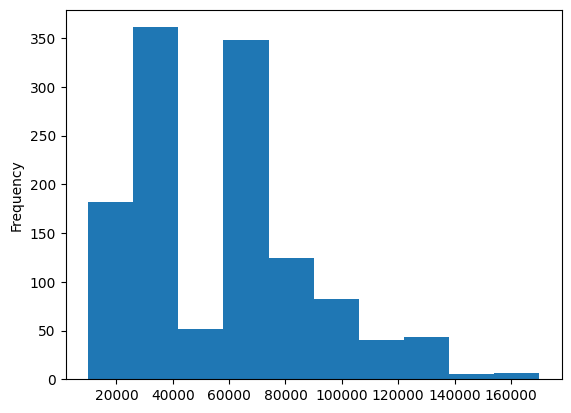

In [8]:
df["Income"].plot.hist()

<Axes: ylabel='Density'>

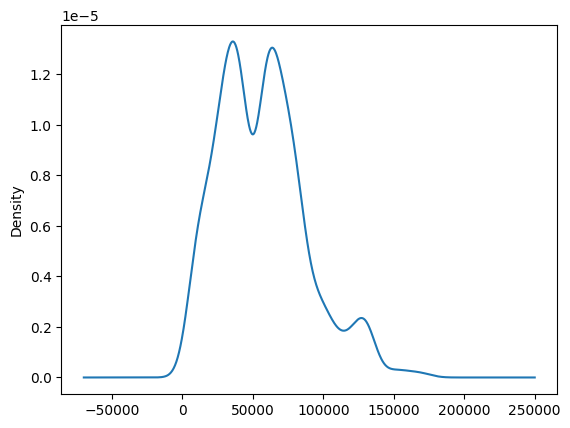

In [9]:
df["Income"].plot.kde()

* Children

<Axes: >

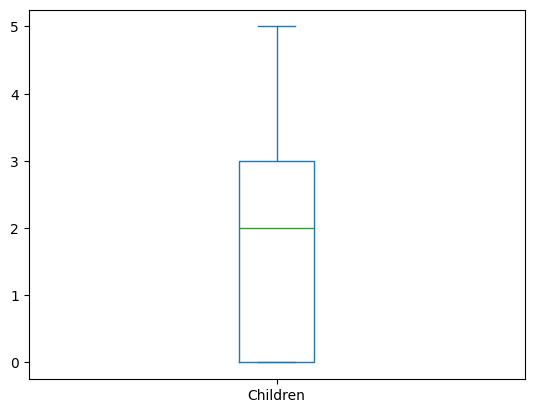

In [10]:
df["Children"].plot.box()

No se encuentran valores atípicos en la gráfica

<Axes: ylabel='Frequency'>

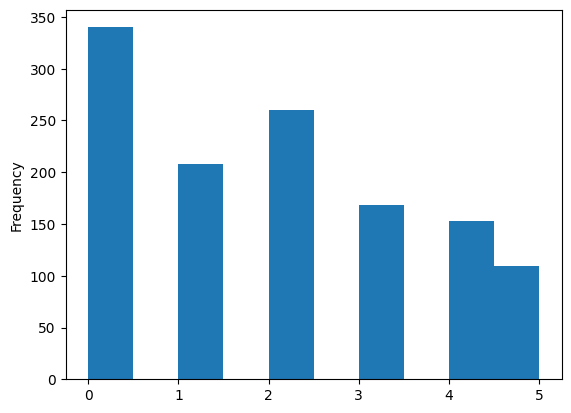

In [11]:
df["Children"].plot.hist()

<Axes: ylabel='Density'>

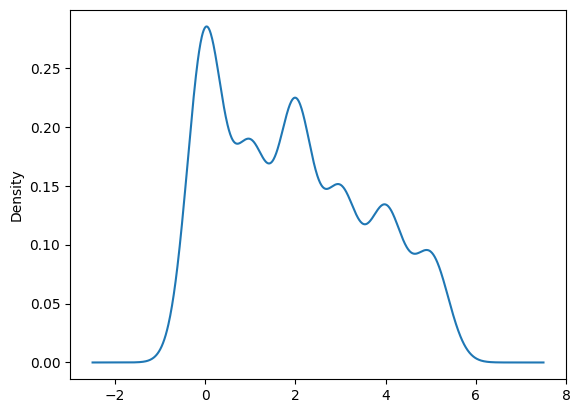

In [12]:
df["Children"].plot.kde()

* Cars

<Axes: >

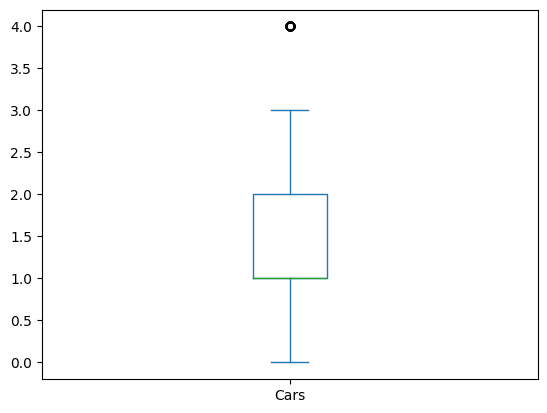

In [13]:
df["Cars"].plot.box()

<Axes: ylabel='Frequency'>

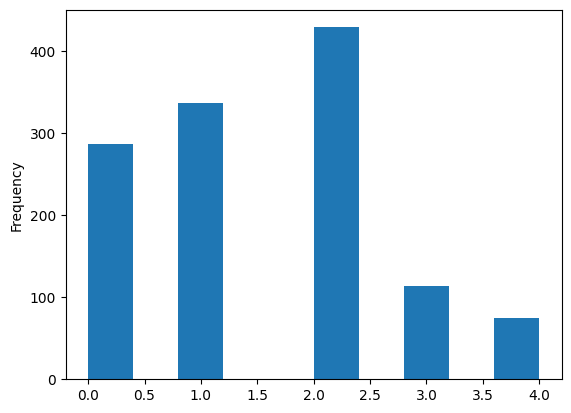

In [14]:
df["Cars"].plot.hist()

<Axes: ylabel='Density'>

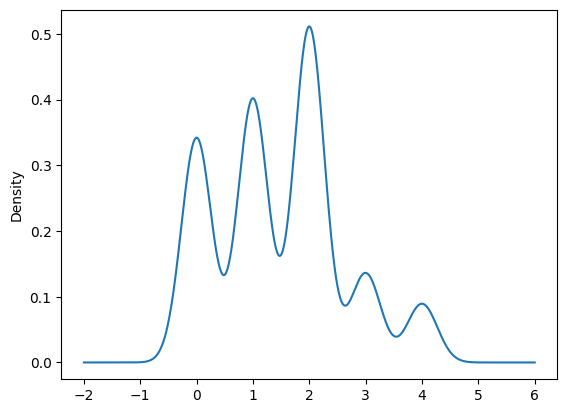

In [15]:
df["Cars"].plot.kde()

* Age

<Axes: >

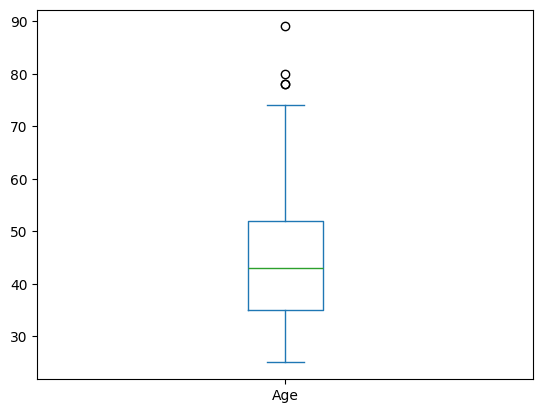

In [16]:
df["Age"].plot.box()

<Axes: ylabel='Frequency'>

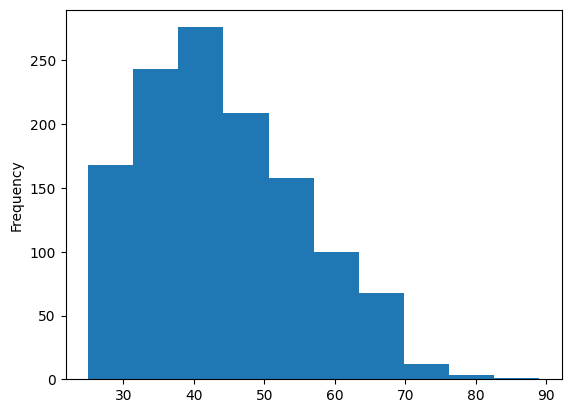

In [17]:
df["Age"].plot.hist()

<Axes: ylabel='Density'>

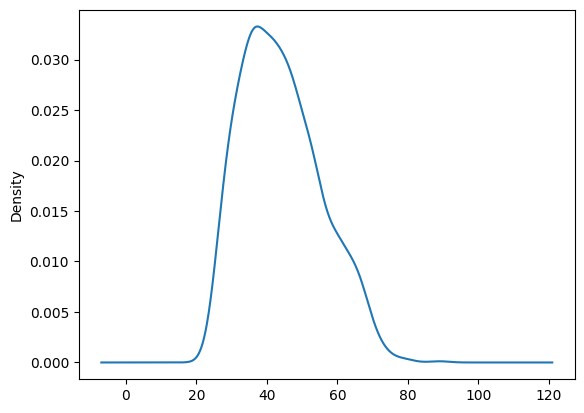

In [18]:
df["Age"].plot.kde()

### 6. Verificamos los duplicados
* Lo hacemos especificamente por ID, ya que este valor debería de ser único y no repetirse

In [19]:
df[df.duplicated(subset=["ID"])]

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
57,20598,Married,Male,100000.0,3.0,Partial High School,Professional,Yes,0.0,10+ Miles,Europe,59.0,Yes
98,19562,Single,Female,60000.0,2.0,Bachelors,Professional,Yes,1.0,2-5 Miles,Pacific,37.0,Yes
116,11270,Married,Male,130000.0,2.0,Graduate Degree,Management,Yes,3.0,0-1 Miles,North America,42.0,Yes
128,20380,Married,Female,60000.0,3.0,Graduate Degree,Management,Yes,2.0,10+ Miles,North America,69.0,No
133,20897,Married,Female,30000.0,1.0,Bachelors,Skilled Manual,Yes,2.0,0-1 Miles,Europe,40.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,21770,Married,Male,60000.0,4.0,Bachelors,Management,Yes,2.0,10+ Miles,North America,60.0,No
1244,14193,Single,Female,100000.0,3.0,Partial College,Management,Yes,4.0,10+ Miles,Europe,56.0,No
1246,19364,Married,Male,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,43.0,Yes
1247,26305,Single,Female,60000.0,2.0,Bachelors,Skilled Manual,No,0.0,0-1 Miles,North America,36.0,Yes


## Limpieza de Datos
Pasos para llevar a cabo la limpieza de datos:

* Borramos las filas que tienen el ID duplicado

In [20]:
df = df.drop_duplicates(subset=["ID"])

* Rellenar valores faltantes en las columnas numéricas

In [21]:
df = df.fillna({
    "Income": df["Income"].median(),
    "Children": df["Children"].mean(),
    "Cars": df["Cars"].median(),
    "Age": df["Age"].median()
})

* Rellenar valores faltantes en las columnas no numéricas

In [22]:
df = df.fillna({
    "Marital Status": df["Marital Status"].mode()[0],
    "Gender": df["Gender"].mode()[0],
    "Home Owner": df["Home Owner"].mode()[0],
})

## Verificación
* Verificar si todos los datos nulos fueron rellenados

In [23]:
print("\nDatos nulos después de la limpieza:")
print(df.isnull().sum())


Datos nulos después de la limpieza:
ID                  0
Marital Status      0
Gender              0
Income              0
Children            0
Education           0
Occupation          0
Home Owner          0
Cars                0
Commute Distance    0
Region              0
Age                 0
Purchased Bike      0
dtype: int64


* Verificar los tipos de datos de cada columna, en especial de Income. Así como la eliminación de las filas con ID duplicado.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1249
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital Status    1000 non-null   object 
 2   Gender            1000 non-null   object 
 3   Income            1000 non-null   float64
 4   Children          1000 non-null   float64
 5   Education         1000 non-null   object 
 6   Occupation        1000 non-null   object 
 7   Home Owner        1000 non-null   object 
 8   Cars              1000 non-null   float64
 9   Commute Distance  1000 non-null   object 
 10  Region            1000 non-null   object 
 11  Age               1000 non-null   float64
 12  Purchased Bike    1000 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 109.4+ KB


* Creación del nuevo archivo con la limpieza realizada

In [25]:
df.to_csv("Actividad/bike_buyers_clean.csv", index=False)